In [51]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, Normalize
import seaborn as sns
from statsmodels.tsa.stattools import grangercausalitytests, ccf
import numpy as np
import plotly.express as px
from datetime import datetime
import geopandas as gpd
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
import utils #from utils import *
import more_utils
import json
import pickle
from pmdarima import auto_arima 
from sklearn.model_selection import train_test_split
import importlib
from scipy import signal
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX 
from random import random
from sklearn.linear_model import LinearRegression as LR

In [2]:
importlib.reload(more_utils)

<module 'more_utils' from '/projects/anzu2965/Classes/Erdos/Final_Project/more_utils.py'>

In [2]:
# read in data
df_power = pd.read_csv('./data/eaglei_data/eaglei_outages_2023.csv')
df_events_fips = pd.read_csv("./data/NOAA_StormEvents/StormEvents_2014_2024_fips.csv")

In [3]:
df_events = pd.read_csv("./data/NOAA_StormEvents/StormEvents_2014_2024.csv")
df_events.columns

Index(['BEGIN_YEARMONTH', 'BEGIN_DAY', 'BEGIN_TIME', 'END_YEARMONTH',
       'END_DAY', 'END_TIME', 'EPISODE_ID', 'EVENT_ID', 'STATE', 'STATE_FIPS',
       'YEAR', 'MONTH_NAME', 'EVENT_TYPE', 'CZ_TYPE', 'CZ_FIPS', 'CZ_NAME',
       'WFO', 'BEGIN_DATE_TIME', 'CZ_TIMEZONE', 'END_DATE_TIME',
       'INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT',
       'DEATHS_INDIRECT', 'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'SOURCE',
       'MAGNITUDE', 'MAGNITUDE_TYPE', 'FLOOD_CAUSE', 'CATEGORY', 'TOR_F_SCALE',
       'TOR_LENGTH', 'TOR_WIDTH', 'TOR_OTHER_WFO', 'TOR_OTHER_CZ_STATE',
       'TOR_OTHER_CZ_FIPS', 'TOR_OTHER_CZ_NAME', 'BEGIN_RANGE',
       'BEGIN_AZIMUTH', 'BEGIN_LOCATION', 'END_RANGE', 'END_AZIMUTH',
       'END_LOCATION', 'BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON',
       'EPISODE_NARRATIVE', 'EVENT_NARRATIVE', 'DATA_SOURCE'],
      dtype='object')

In [5]:
#df_events_fips = pd.read_parquet('./data/NOAA_Cleaned_ExplodedFIPS.parquet')
#df_events_fips.to_csv('./data/NOAA_StormEvents_Aaron/StormEvents_2014_2024_fips_Aaron.csv')
df_events_fips = pd.read_csv('./data/NOAA_StormEvents_Aaron/StormEvents_2014_2024_fips_Aaron.csv')

In [6]:
df_events_fips

,Unnamed: 0,EVENT_TYPE,BEGIN_DATE_TIME,CZ_TIMEZONE,END_DATE_TIME,INJURIES_DIRECT,INJURIES_INDIRECT,DEATHS_DIRECT,DEATHS_INDIRECT,DAMAGE_PROPERTY,...,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,STATE_ABBREV,FIPS,Number_of_FIPS,total_duration_min,total_duration_perfips_min,Subregion
0,0,Heavy Snow,2014-02-18 10:00:00,EST-5,2014-02-18 20:00:00,0,0,0,0,0.00K,...,NaN,NaN,Low pressure developing south of Long Island a...,Eight to twelve inches of snow fell across eas...,NH,33011.0,1,600.0,600.0,NEWE
1,1,Flood,2014-03-30 08:31:00,EST-5,2014-03-30 09:31:00,0,0,0,0,35.00K,...,42.5867,-71.3469,A stacked low pressure system passed south and...,Boston Road was closed near Brian Road due to ...,MA,25017.0,1,60.0,60.0,NEWE
2,2,Hail,2014-04-27 23:06:00,CST-6,2014-04-27 23:06:00,0,0,0,0,0.00K,...,36.9500,-92.6600,A powerful storm system and a dry line produce...,NaN,MO,29067.0,1,0.0,0.0,SRMW
3,3,Thunderstorm Wind,2014-04-27 23:03:00,CST-6,2014-04-27 23:03:00,0,0,0,0,10.00K,...,36.9500,-92.6600,A powerful storm system and a dry line produce...,Several power poles snapped and trees blown down.,MO,29067.0,1,0.0,0.0,SRMW
4,4,High Wind,2014-02-15 13:00:00,PST-8,2014-02-15 21:00:00,0,0,0,0,0.00K,...,NaN,NaN,A strong cold front produced strong winds for ...,Two stations measured strong wind gusts in the...,WA,53059.0,1,480.0,480.0,NWPP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
287995,287995,Heavy Snow,2018-02-17 03:00:00,PST-8,2018-02-18 11:00:00,0,0,0,0,0.00K,...,NaN,NaN,A stationary front laying west to east over ea...,An observer at Bonners Ferry recorded 10.2 inc...,ID,16055.0,1,1920.0,1920.0,NWPP
287996,287996,Winter Storm,2018-02-14 21:33:00,MST-7,2018-02-14 21:33:00,0,0,0,0,0.00K,...,NaN,NaN,"Late in the afternoon of February 14th, a cold...",Severe driving conditions due to snow and blow...,MT,30067.0,1,0.0,0.0,NWPP
287997,287997,Thunderstorm Wind,2018-02-11 02:53:00,CST-6,2018-02-11 02:53:00,0,0,0,0,25.00K,...,30.7700,-85.8100,"For the first time since January 2017, an even...",A tree fell on a house in Caryville. Reported...,FL,12133.0,1,0.0,0.0,SRSO
287998,287998,Heavy Snow,2018-03-13 05:00:00,EST-5,2018-03-14 09:00:00,0,0,0,0,0.00K,...,NaN,NaN,Low pressure off the Southeast U.S. coast on t...,NaN,ME,23015.0,1,1680.0,1680.0,NEWE


## 1) Basic approuch using state level data as given in example notebook

First let's do some data cleaning and visualization:

In [7]:
# Read in and aggregaate one state
state = 'Colorado'#'Washington'
#fips_code = #08013# 29067 #53033 # King County, WA
start_year = 2018
start_month = 1
start_day = 1
end_year = 2021
end_month = 12
end_day = 30
df_state_ts_comb_hr, df_state_ts_comb_day = utils.combine_agg_ts(state = state,
#df_county_ts_comb_hr, df_county_ts_comb_day = more_utils.combine_agg_ts_county(fips_code = fips_code,
                                                     start_year = start_year,
                                                     start_month = start_month,
                                                     start_day = start_day,
                                                     end_year = end_year,
                                                     end_month = end_month,
                                                     end_day = end_day,
                                                     data_directory_power = './data/eaglei_data',
                                                     data_directory_events = './data/NOAA_StormEvents')

#train_data, test_data = train_test_split(df_state_ts_comb_hr, test_size=0.20, random_state=42)
train_data, test_data = train_test_split(df_state_ts_comb_hr, test_size=0.20, random_state=42)

In [18]:
# Read in and aggregaate one county
#state = 'Colorado'#'Washington'
fips_code = 44007#29067 #53033 # King County, WA
start_year = 2018
start_month = 1
start_day = 1
end_year = 2021
end_month = 12
end_day = 30
#df_state_ts_comb_hr, df_state_ts_comb_day = utils.combine_agg_ts(state = state,
df_county_ts_comb_hr, df_county_ts_comb_day = more_utils.combine_agg_ts_county(fips_code = fips_code,
                                                     start_year = start_year,
                                                     start_month = start_month,
                                                     start_day = start_day,
                                                     end_year = end_year,
                                                     end_month = end_month,
                                                     end_day = end_day,
                                                     data_directory_power = './data/eaglei_data',
                                                     data_directory_events = './data/NOAA_StormEvents')

train_data, test_data = train_test_split(df_county_ts_comb_hr, test_size=0.20, random_state=42)
#train_data, test_data = train_test_split(df_state_ts_comb_hr, test_size=0.20, random_state=42)

In [8]:
df_state_ts_comb_hr

,event_count High Wind,event_count Winter Storm,event_count Drought,event_count Avalanche,event_count Hail,event_count Winter Weather,event_count Tornado,event_count Flash Flood,event_count Thunderstorm Wind,event_count Lightning,...,event_count Extreme Cold/Wind Chill,event_count Strong Wind,event_count Dust Storm,event_count Dense Smoke,event_count Ice Storm,event_count Freezing Fog,event_count Heat,event_count Excessive Heat,event_count Cold/Wind Chill,customers_out
time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.000000
2018-01-01 01:00:00,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.750000
2018-01-01 02:00:00,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.250000
2018-01-01 03:00:00,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.000000
2018-01-01 04:00:00,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-30 19:00:00,0.75,10.0,25.0,0.0,0.0,3.75,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25196.500000
2021-12-30 20:00:00,0.25,10.0,25.0,0.0,0.0,4.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40827.750000
2021-12-30 21:00:00,0.75,10.0,25.0,0.0,0.0,4.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,46054.250000


In [22]:
# sort
train_data = train_data.sort_values('time')

#z-score normalize
train_normed = train_data.copy()
for column in train_normed.columns: 
    if column != 'customers_out':
        train_normed[column] = (train_normed[column] -
                               train_normed[column].mean()) / train_normed[column].std()   

# let null values be zero counts
train_normed[np.isnan(train_normed)] = 0

# remove cols with only zero values
for column in train_normed.columns: 
    if bool((train_normed[column] == 0).all()):
        train_normed = train_normed.drop(columns = [column])
        
# split X and y
X_train = train_normed.drop(columns=['customers_out'])
y_train = train_normed['customers_out']
X_train

# sort
test_data = test_data.sort_values('time')

#z-score normalize
test_normed = test_data.copy()
for column in test_normed.columns: 
    test_normed[column] = (test_normed[column] -
                           test_normed[column].mean()) / test_normed[column].std()   

# let null values be zero counts
test_normed[np.isnan(test_normed)] = 0

# remove cols with only zero values
for column in test_normed.columns: 
    if bool((test_normed[column] == 0).all()):
        test_normed = test_normed.drop(columns = [column])
        
# split X and y
X_test = test_normed.drop(columns=['customers_out'])
y_test = test_normed['customers_out']


In [23]:
X_train

,event_count High Wind,event_count Winter Storm,event_count Drought,event_count Avalanche,event_count Hail,event_count Winter Weather,event_count Tornado,event_count Flash Flood,event_count Thunderstorm Wind,event_count Lightning,...,event_count Wildfire,event_count Dust Devil,event_count Debris Flow,event_count Extreme Cold/Wind Chill,event_count Strong Wind,event_count Dust Storm,event_count Dense Smoke,event_count Freezing Fog,event_count Heat,event_count Excessive Heat
time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,-0.101798,-0.136303,-1.269698,-0.027055,-0.086393,-0.301053,-0.035679,-0.081988,-0.048823,-0.017921,...,-0.621058,-0.005973,-0.044766,-0.044423,-0.016514,-0.025171,-0.089011,-0.005973,-0.048466,-0.053977
2018-01-01 01:00:00,-0.101798,-0.136303,-1.269698,-0.027055,-0.086393,-0.301053,-0.035679,-0.081988,-0.048823,-0.017921,...,-0.621058,-0.005973,-0.044766,-0.044423,-0.016514,-0.025171,-0.089011,-0.005973,-0.048466,-0.053977
2018-01-01 02:00:00,-0.101798,-0.136303,-1.269698,-0.027055,-0.086393,-0.301053,-0.035679,-0.081988,-0.048823,-0.017921,...,-0.621058,-0.005973,-0.044766,-0.044423,-0.016514,-0.025171,-0.089011,-0.005973,-0.048466,-0.053977
2018-01-01 03:00:00,-0.101798,-0.136303,-1.269698,-0.027055,-0.086393,-0.301053,-0.035679,-0.081988,-0.048823,-0.017921,...,-0.621058,-0.005973,-0.044766,-0.044423,-0.016514,-0.025171,-0.089011,-0.005973,-0.048466,-0.053977
2018-01-01 05:00:00,-0.101798,-0.136303,-1.269698,-0.027055,-0.086393,-0.301053,-0.035679,-0.081988,-0.048823,-0.017921,...,-0.621058,-0.005973,-0.044766,-0.044423,-0.016514,-0.025171,-0.089011,-0.005973,-0.048466,-0.053977
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-30 16:00:00,2.272581,2.806080,1.158772,-0.027055,-0.086393,1.108599,-0.035679,-0.081988,-0.048823,-0.017921,...,-0.221712,-0.005973,-0.044766,-0.044423,-0.016514,-0.025171,-0.089011,-0.005973,-0.048466,-0.053977
2021-12-30 17:00:00,2.272581,2.960942,1.158772,-0.027055,-0.086393,1.108599,-0.035679,-0.081988,-0.048823,-0.017921,...,-0.221712,-0.005973,-0.044766,-0.044423,-0.016514,-0.025171,-0.089011,-0.005973,-0.048466,-0.053977
2021-12-30 19:00:00,0.491797,2.960942,1.158772,-0.027055,-0.086393,1.461012,-0.035679,-0.081988,-0.048823,-0.017921,...,-0.221712,-0.005973,-0.044766,-0.044423,-0.016514,-0.025171,-0.089011,-0.005973,-0.048466,-0.053977


In [24]:
X_train

,event_count High Wind,event_count Winter Storm,event_count Drought,event_count Avalanche,event_count Hail,event_count Winter Weather,event_count Tornado,event_count Flash Flood,event_count Thunderstorm Wind,event_count Lightning,...,event_count Wildfire,event_count Dust Devil,event_count Debris Flow,event_count Extreme Cold/Wind Chill,event_count Strong Wind,event_count Dust Storm,event_count Dense Smoke,event_count Freezing Fog,event_count Heat,event_count Excessive Heat
time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,-0.101798,-0.136303,-1.269698,-0.027055,-0.086393,-0.301053,-0.035679,-0.081988,-0.048823,-0.017921,...,-0.621058,-0.005973,-0.044766,-0.044423,-0.016514,-0.025171,-0.089011,-0.005973,-0.048466,-0.053977
2018-01-01 01:00:00,-0.101798,-0.136303,-1.269698,-0.027055,-0.086393,-0.301053,-0.035679,-0.081988,-0.048823,-0.017921,...,-0.621058,-0.005973,-0.044766,-0.044423,-0.016514,-0.025171,-0.089011,-0.005973,-0.048466,-0.053977
2018-01-01 02:00:00,-0.101798,-0.136303,-1.269698,-0.027055,-0.086393,-0.301053,-0.035679,-0.081988,-0.048823,-0.017921,...,-0.621058,-0.005973,-0.044766,-0.044423,-0.016514,-0.025171,-0.089011,-0.005973,-0.048466,-0.053977
2018-01-01 03:00:00,-0.101798,-0.136303,-1.269698,-0.027055,-0.086393,-0.301053,-0.035679,-0.081988,-0.048823,-0.017921,...,-0.621058,-0.005973,-0.044766,-0.044423,-0.016514,-0.025171,-0.089011,-0.005973,-0.048466,-0.053977
2018-01-01 05:00:00,-0.101798,-0.136303,-1.269698,-0.027055,-0.086393,-0.301053,-0.035679,-0.081988,-0.048823,-0.017921,...,-0.621058,-0.005973,-0.044766,-0.044423,-0.016514,-0.025171,-0.089011,-0.005973,-0.048466,-0.053977
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-30 16:00:00,2.272581,2.806080,1.158772,-0.027055,-0.086393,1.108599,-0.035679,-0.081988,-0.048823,-0.017921,...,-0.221712,-0.005973,-0.044766,-0.044423,-0.016514,-0.025171,-0.089011,-0.005973,-0.048466,-0.053977
2021-12-30 17:00:00,2.272581,2.960942,1.158772,-0.027055,-0.086393,1.108599,-0.035679,-0.081988,-0.048823,-0.017921,...,-0.221712,-0.005973,-0.044766,-0.044423,-0.016514,-0.025171,-0.089011,-0.005973,-0.048466,-0.053977
2021-12-30 19:00:00,0.491797,2.960942,1.158772,-0.027055,-0.086393,1.461012,-0.035679,-0.081988,-0.048823,-0.017921,...,-0.221712,-0.005973,-0.044766,-0.044423,-0.016514,-0.025171,-0.089011,-0.005973,-0.048466,-0.053977


High Wind Count and Blizzard Count:0.21792689143376412
High Wind Count and Dust Storm Count:0.2721842043096553
Winter Storm Count and Winter Weather Count:0.3246382097910539
Winter Storm Count and Heavy Snow Count:0.22846363083291493
Drought Count and Wildfire Count:0.2672000724345999
Winter Weather Count and Winter Storm Count:0.3246382097910539
Winter Weather Count and Heavy Snow Count:0.36618868347977435
Heavy Snow Count and Winter Storm Count:0.22846363083291493
Heavy Snow Count and Winter Weather Count:0.36618868347977435
Blizzard Count and High Wind Count:0.21792689143376412
Wildfire Count and Drought Count:0.2672000724345999
Dust Storm Count and High Wind Count:0.2721842043096553


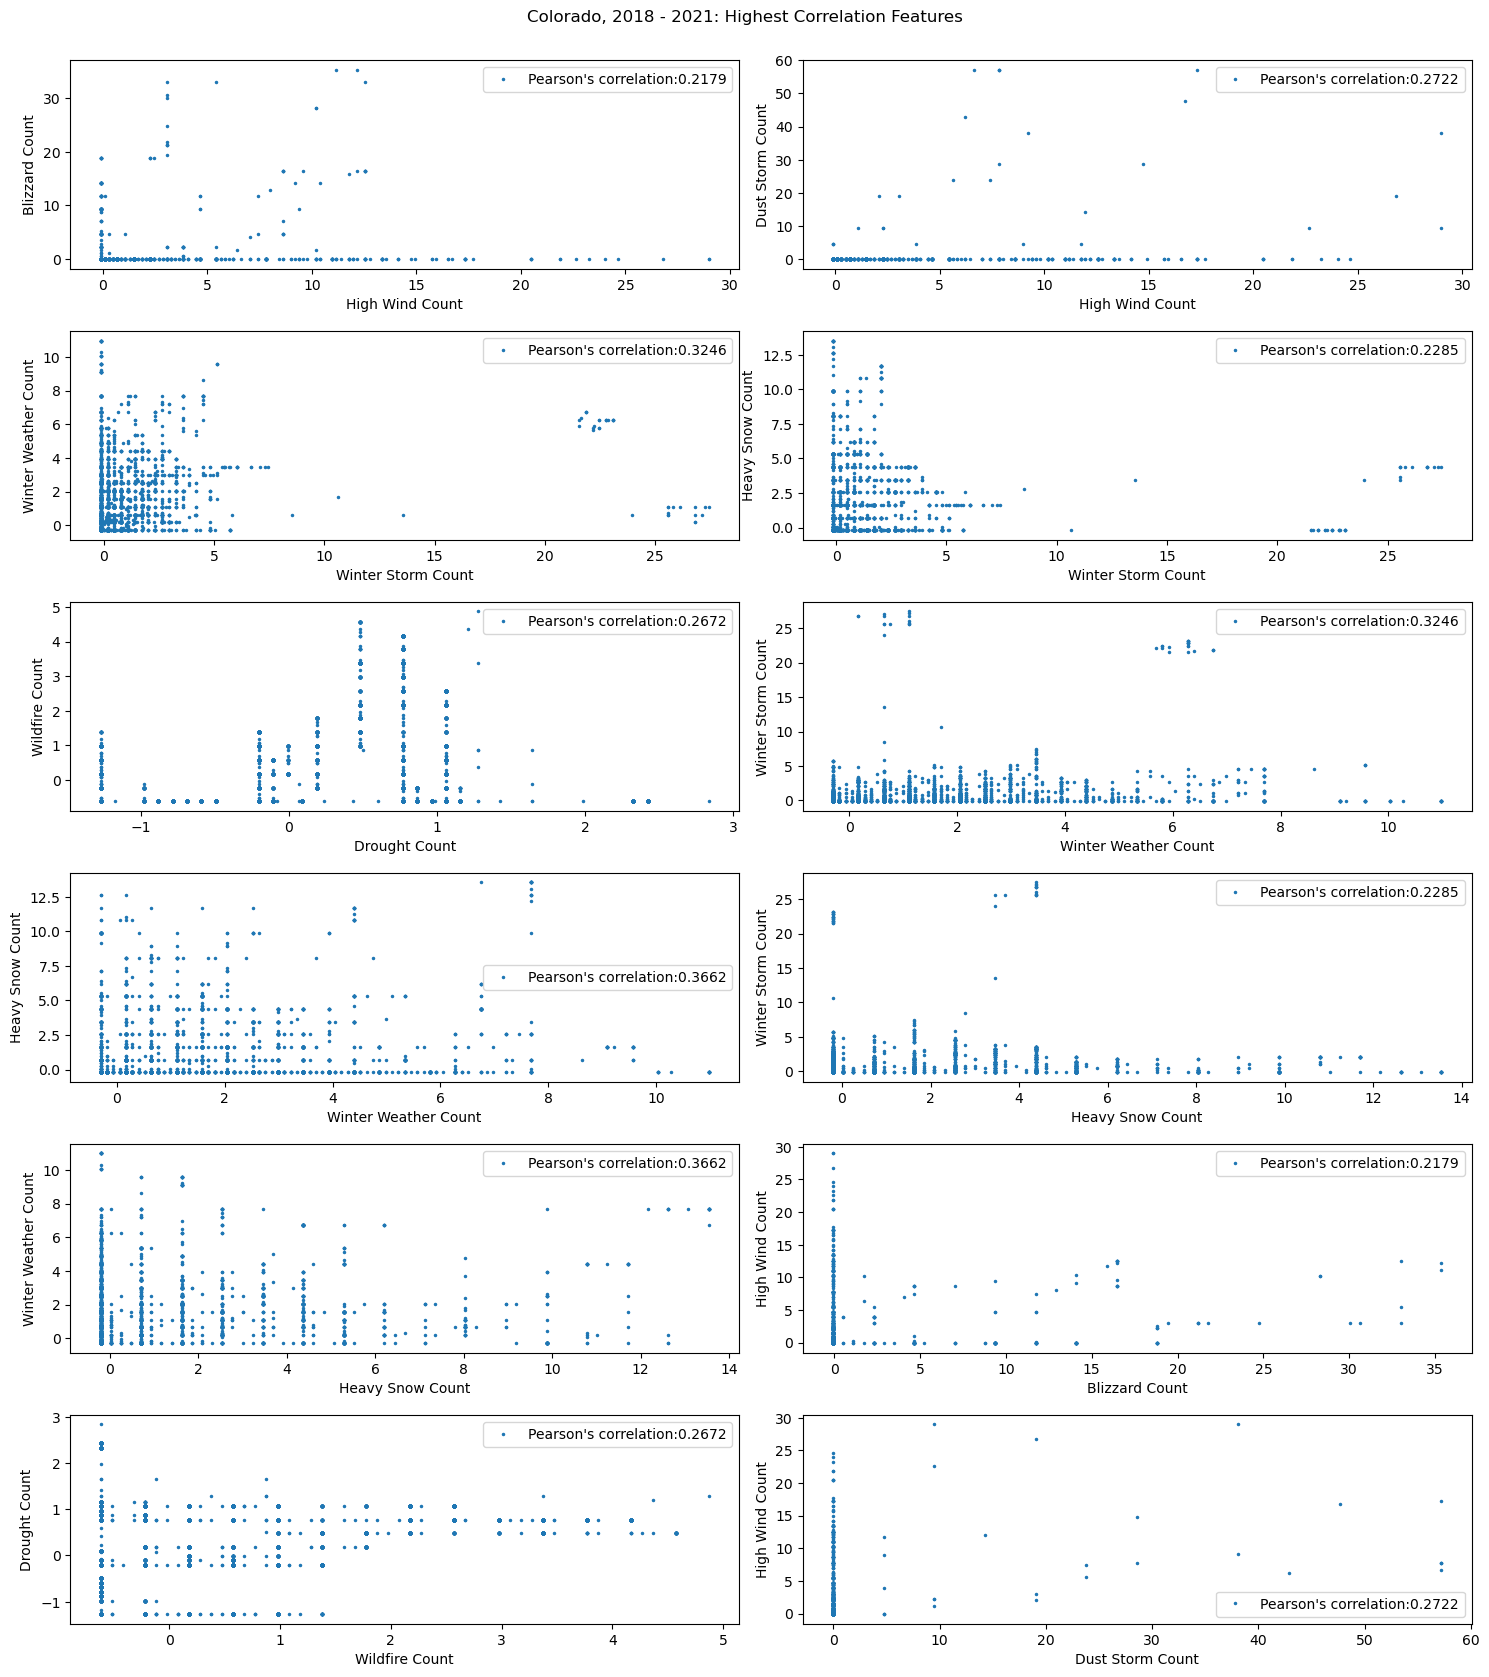

In [18]:
# are there stron correlations between variables?
plt.figure(figsize = [15,20])
cols = X_train.columns
n = 1
for i in range(len(cols)):
    xcol = cols[i]
    for j in range(len(cols)):
        ycol = cols[j]
        x = X_train[xcol]
        y = X_train[ycol]
        xlabel = xcol.replace('event_count ', '') + ' Count'
        ylabel = ycol.replace('event_count ', '') + ' Count'
        r = np.sum((x - np.nanmean(x))*(y - np.nanmean(y))) / np.sqrt(np.sum((x - np.nanmean(x))**2)*np.sum((y - np.nanmean(y))**2))
        if (r > 0.2) and r != 1: 
            print(xlabel + ' and ' + ylabel + ':' + str(r))
            plt.subplot(7,2,n)
            plt.plot(x, y, '.', alpha = 1.0, label = 'Pearson\'s correlation:' + str(np.round(r,4)), ms = 3)
            plt.ylabel(ylabel)
            plt.xlabel(xlabel)
            plt.legend()
            n+=1
plt.suptitle(state + ', ' + str(start_year) + ' - ' + str(end_year) + ': Highest Correlation Features')
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) 

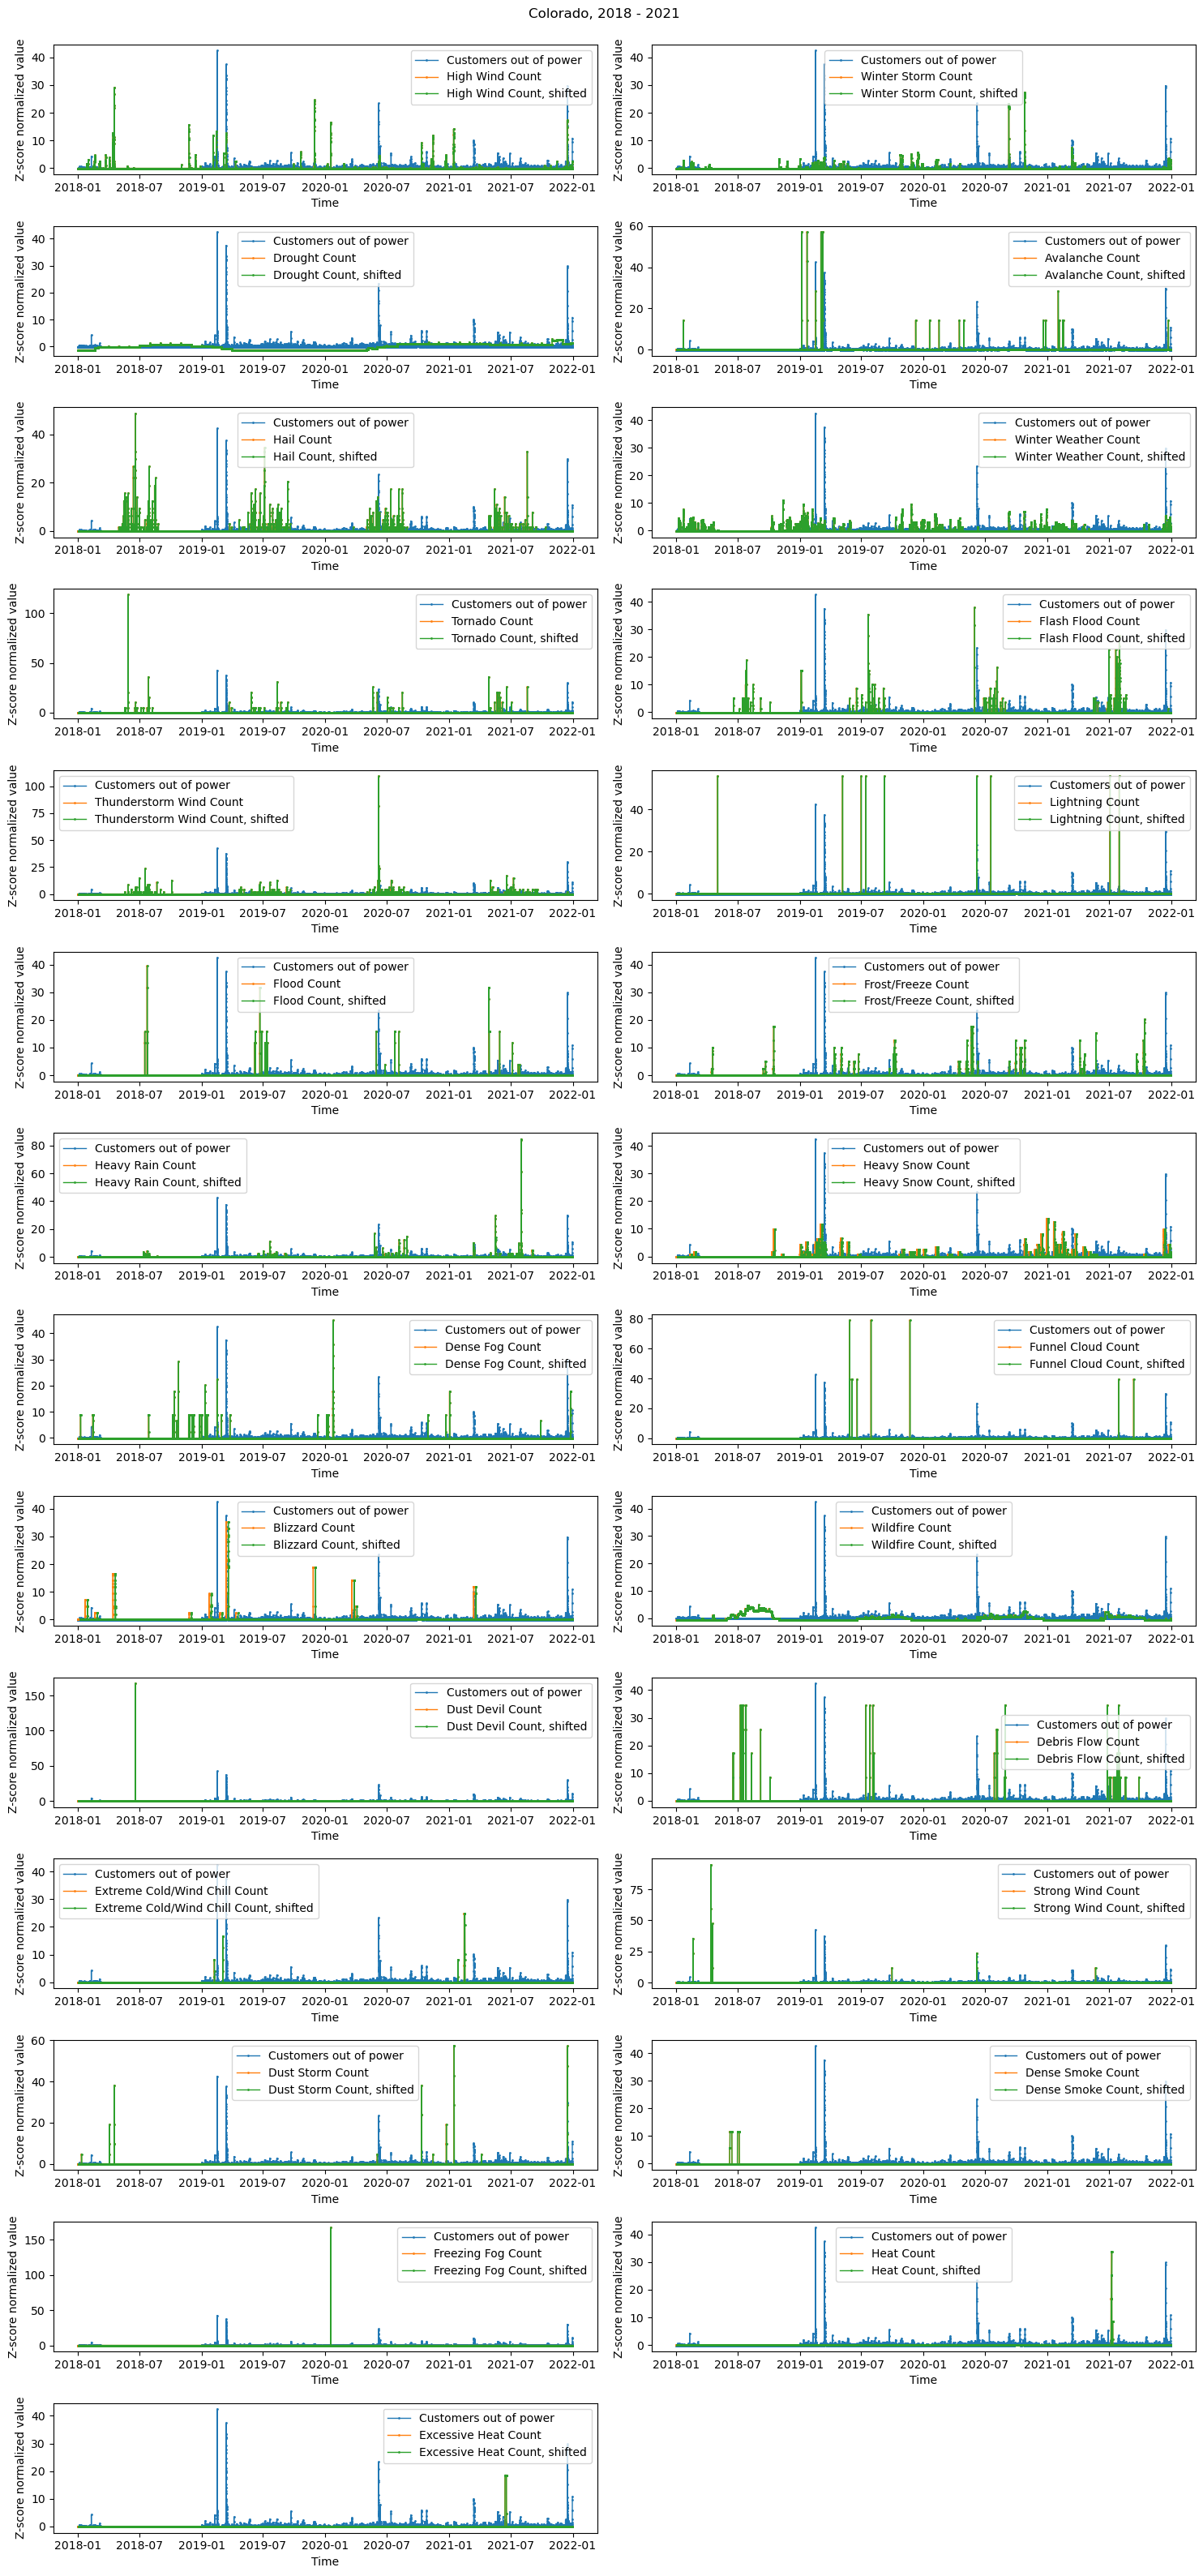

In [10]:
# compute best lags bestween predictors and target
def compute_shift(x, y):
    shift_vals = np.arange(1,8*24,1)
    metrics = np.zeros(len(shift_vals))
    for i in range(len(shift_vals)): # let's say no more than a week is reasonable
        shift_val = shift_vals[i]
        x_shift = x[:-shift_val]
        y_shift = y[shift_val:]
        metric = np.sum((x_shift - np.nanmean(x_shift))*(y_shift - np.nanmean(y_shift))) / np.sqrt(np.sum((x_shift - np.nanmean(x_shift))**2)*np.sum((y_shift - np.nanmean(y_shift))**2))
#np.corrcoef(y_shift,x_shift) # np.sum(y[shift_val:]*x[:-shift_val])
        metrics[i] = metric
    return (shift_vals[metrics == np.nanmax(metrics)])[0]
   

# plot parameters and find best shift values
plt.figure(figsize = [15,40])
cols = X_train.columns
shifts = []
for i in range(len(cols)):
    plt.subplot(17,2,i+1)
    col = cols[i]
    label = col.replace('event_count ', '') + ' Count'
    shift = compute_shift(X_train[col], y_train)
    shifts += [shift]
    plt.plot(X_train.index, y_train, '.-', ms = 2, lw = 1, label = 'Customers out of power')
    plt.plot(X_train.index, X_train[col], '.-', ms = 2, lw = 1, label = label)
    plt.plot(X_train.index[shift:], X_train[col][:-shift], '.-', ms = 2, lw = 1, label = label + ', shifted')
    plt.legend()
    plt.ylabel('Z-score normalized value')
    plt.xlabel('Time')
plt.suptitle(state + ', ' + str(start_year) + ' - ' + str(end_year))
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) 
# plt.subplots_adjust(top=3)

In [22]:
# some models require stationarity, let's check for that!

def adf_test(series,title=''):
    """
    FROM: http://analyticsvidhya.com/blog/2021/08/vector-autoregressive-model-in-python/
    Pass in a time series and an optional title, returns an ADF report
    """
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna(),autolag='AIC') # .dropna() handles differenced data
    labels = ['ADF test statistic','p-value','# lags used','# observations']
    out = pd.Series(result[0:4],index=labels)
    for key,val in result[4].items():
        out[f'critical value ({key})']=val
    print(out.to_string())          # .to_string() removes the line "dtype: float64"
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")
        
# check if stationary
cols = X_train.columns
for i in range(len(cols)):
    print(cols[i])
    adf_test(X_train[cols[i]])
    print()

event_count High Wind
Augmented Dickey-Fuller Test: 
ADF test statistic        -26.635151
p-value                     0.000000
# lags used                18.000000
# observations          28013.000000
critical value (1%)        -3.430583
critical value (5%)        -2.861643
critical value (10%)       -2.566825
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary

event_count Winter Storm
Augmented Dickey-Fuller Test: 
ADF test statistic        -19.726407
p-value                     0.000000
# lags used                43.000000
# observations          27988.000000
critical value (1%)        -3.430584
critical value (5%)        -2.861643
critical value (10%)       -2.566825
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary

event_count Drought
Augmented Dickey-Fuller Test: 
ADF test statistic         -1.495069
p-value                     0.535949
# lags used             

#### SARIMAX

After some googling, it looks like the Varimax algorithm is designed for multivariate timeseries predictions. Let's try that. 

In [35]:
# try sarimax
model = SARIMAX(train_normed['customers_out'])#, order = (0, 1, 1), seasonal_order =(2, 1, 1, 12)) 
result = model.fit() 
result.summary() 

/projects/anzu2965/software/anaconda/envs/erdos_spring_2025/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/projects/anzu2965/software/anaconda/envs/erdos_spring_2025/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:          customers_out   No. Observations:                28032
Model:               SARIMAX(1, 0, 0)   Log Likelihood             -252801.094
Date:                Wed, 19 Mar 2025   AIC                         505606.189
Time:                        10:35:12   BIC                         505622.671
Sample:                             0   HQIC                        505611.495
                              - 28032                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8857      0.000   5892.197      0.000       0.885       0.886
sigma2      3.988e+06    855.030   4663.748      0.000    3.99e+06    3.99e+06
===================================================================================
Ljung-Box (L1) (Q):                 608.75   Jarque-Bera (JB):       18815680305.96
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.35   Skew:                            18.37
Prob(H) (two-sided):                  0.00   Kurtosis:                      4016.47
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<Axes: xlabel='time'>

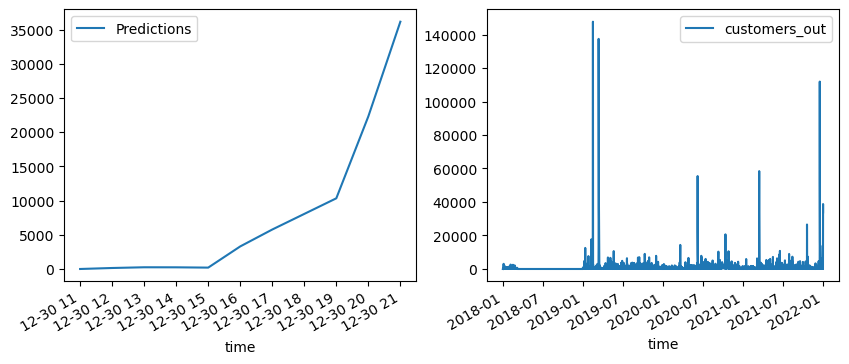

In [41]:
start = train_data.index[-10] #test_data.index[0] #len(train_data) 
end = train_data.index[-1] #test_data.index[-1]  #len(train_data) + len(test_data) - 1
  
# Predictions for one-year against the test set 
predictions = result.predict(start, end, 
                             typ = 'levels').rename("Predictions") 
# plot predictions and actual values 
plt.figure(figsize = [10,4])
plt.subplot(121)
predictions.plot(legend = True) 
plt.subplot(122)
test_data['customers_out'].plot(legend = True) 

Well, that didn't perform very well!

In [31]:
# fit model

model = SARIMAX(y_train, exog=X_train, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0))
model_fit = model.fit(disp=False)
# make prediction
#exog2 = [200 + random()]
yhat = model_fit.predict(len(y_train))#, len(y_train))#, exog=[exog2])
print(yhat)

/projects/anzu2965/software/anaconda/envs/erdos_spring_2025/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/projects/anzu2965/software/anaconda/envs/erdos_spring_2025/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/projects/anzu2965/software/anaconda/envs/erdos_spring_2025/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


ValueError: Out-of-sample operations in a model with a regression component require additional exogenous values via the `exog` argument.

##### VARMAX

In [ ]:
# maybe we can fit the next values for the predictor vars?
from statsmodels.tsa.statespace.varmax import VARMAX

# contrived dataset
# fit model
model = VARMAX(X_train)#, freq = 'D', order=(1,1), seasonal_order=(0, 0, 0, 0), mle_regression = True, filter_concentrated = True)
model_fit = model.fit(disp=True)

# make prediction
yhat = model_fit.predict(len(X_train), len(X_train))

/projects/anzu2965/software/anaconda/envs/erdos_spring_2025/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


### 2) Neural Network

A Neural Network should be able to take into account the timeseries nature of the observations and in the future the spatial relationships as well.

In [ ]:
# NOTE: moved to colab notebook

### 3) Regression, summarizing chunks as much as possible

Washington
Colorado
Rhode Island
California


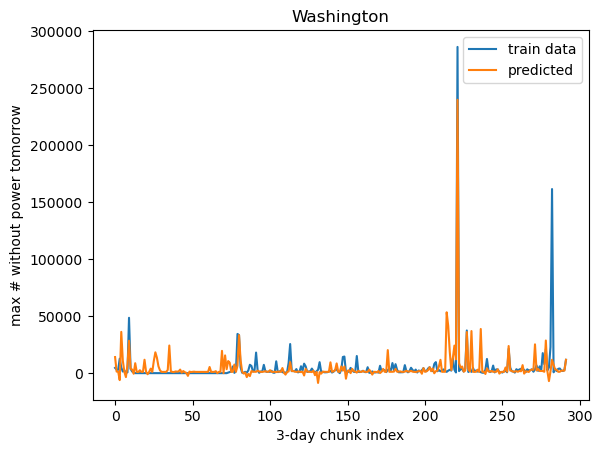

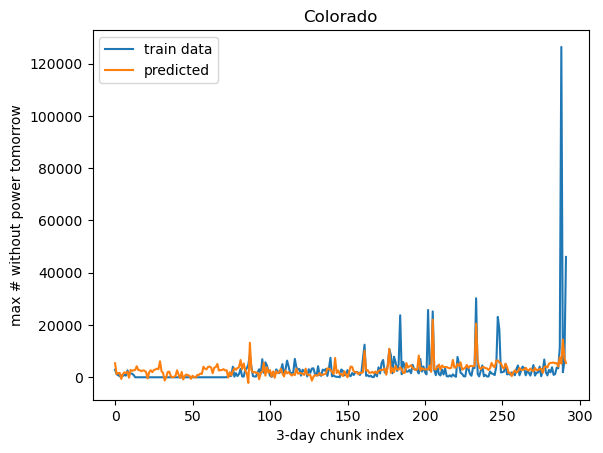

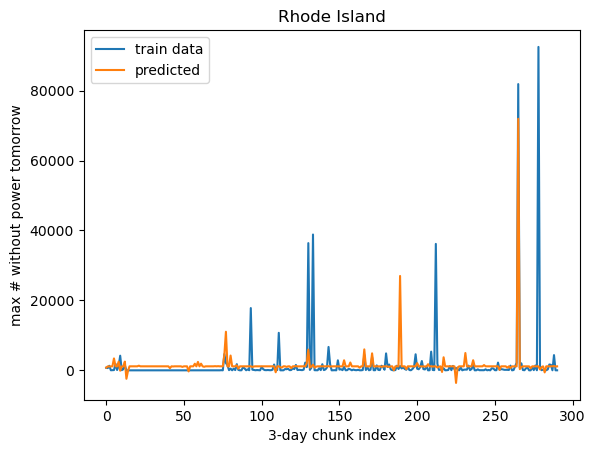

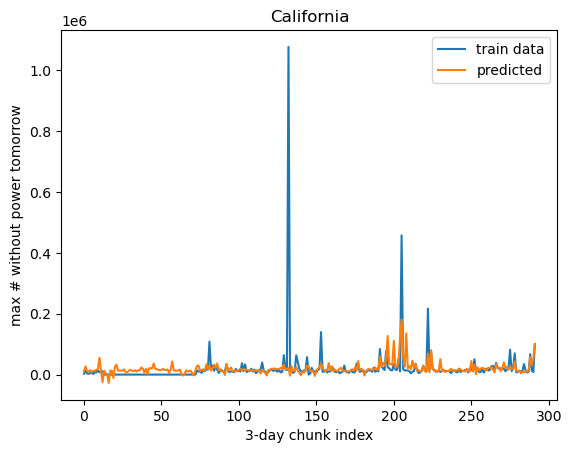

In [92]:
start_year = 2018
start_month = 1
start_day = 1
end_year = 2021
end_month = 12
end_day = 30
cols = ['event_count High Wind', 'event_count Winter Storm', 'event_count Drought', 'event_count Avalanche', 'event_count Hail',
   'event_count Winter Weather', 'event_count Tornado', 'event_count Flash Flood', 'event_count Thunderstorm Wind',
   'event_count Lightning', 'event_count Flood', 'event_count Frost/Freeze', 'event_count Heavy Rain',
   'event_count Heavy Snow', 'event_count Dense Fog', 'event_count Funnel Cloud', 'event_count Blizzard',
   'event_count Wildfire', 'event_count Dust Devil', 'event_count Debris Flow', 'event_count Extreme Cold/Wind Chill',
   'event_count Strong Wind', 'event_count Dust Storm', 'event_count Dense Smoke', 'event_count Ice Storm',
   'event_count Freezing Fog', 'event_count Heat', 'event_count Excessive Heat', 'event_count Cold/Wind Chill', 'trend High Wind', 'trend Winter Storm',
   'trend Drought', 'trend Avalanche', 'trend Hail', 'trend Winter Weather', 'trend Tornado',
   'trend Flash Flood', 'trend Thunderstorm Wind', 'trend Lightning', 'trend Flood',
   'trend Frost/Freeze', 'trend Heavy Rain', 'trend Heavy Snow', 'trend Dense Fog',
   'trend Funnel Cloud', 'trend Blizzard', 'trend Wildfire', 'trend Dust Devil',
   'trend Debris Flow', 'trend Extreme Cold/Wind Chill', 'trend Strong Wind', 'trend Dust Storm',
   'trend Dense Smoke', 'trend Ice Storm', 'trend Freezing Fog', 'trend Heat',
   'trend Excessive Heat', 'trend Cold/Wind Chill', 'count_yesterday', 'count_today']

states = ['Washington','Colorado','Rhode Island','California']
for j in range(len(states)):
    state = states[j]
    print(state)
    if not os.path.exists('./data/X_chunked_2018_2021_' + state + '_short.pkl'):
        df_state_ts_comb_hr, df_state_ts_comb_day = utils.combine_agg_ts(state = state,
                                                             start_year = start_year,
                                                             start_month = start_month,
                                                             start_day = start_day,
                                                             end_year = end_year,
                                                             end_month = end_month,
                                                             end_day = end_day,
                                                             data_directory_power = './data/eaglei_data',
                                                             data_directory_events = './data/NOAA_StormEvents')
        X_chunked, y_chunked = more_utils.make_data_chunks(df_state_ts_comb_hr, 2018, 2021, './data', state + '_short', days_per_chunk = 5, days_per_X = 4, days_per_y = 1)
    else:
        X_chunked = pd.read_pickle('./data/X_chunked_2018_2021_' + state + '_short.pkl')
        y_chunked = pd.read_pickle('./data/y_chunked_2018_2021_' + state + '_short.pkl')
    
    n_chunks = X_chunked.shape[2]
    n_features = X_chunked.shape[1]
    X_train_simple = np.zeros((n_chunks, 2*n_features + 2))
    y_train_simple = np.zeros(n_chunks)
    for i in range(n_chunks):
        X_train_simple[i,:n_features] = np.sum(X_chunked[:,:,i], axis = 0) # total of each event in the last 4 days
        X_train_simple[i,n_features:] = np.mean(X_chunked[:10,:,i]) - np.mean(X_chunked[-10:,:,i]) # measure of magnitude and sign of trend over the 4 days
        X_train_simple[i,-1] =  np.max(y_chunked[:,:,i-2]) # how many max people were without power yesterday
        X_train_simple[i,-2] =  np.max(y_chunked[:,:,i-1]) # how many max people were without power today    
        y_train_simple[i] = np.max(y_chunked[:,:,i]) # max number of people w/o power over the next day
 
    #cols = list(df_state_ts_comb_hr.columns)[0:-1] # remove predictor column name, features might be different per state
    X_train_simple = pd.DataFrame(X_train_simple)#, columns = cols)#.shape
    
    reg = LR().fit(X_train_simple, y_train_simple)
    y_pred = reg.predict(X_train_simple)
    
    plt.figure()
    index = np.linspace(0,n_chunks-1,n_chunks)
    plt.plot(index, y_train_simple, label = 'train data')
    plt.plot(index, y_pred, label = 'predicted')
    plt.xlabel('3-day chunk index')
    plt.ylabel('max # without power tomorrow')
    plt.title(state)
    plt.legend()